# Chapter 3 : Maryland Automotive Industry - Detailed Segment Analysis

#### Import Packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

#### Import Data

In [2]:
# load in cyclical data
cyclical_data = pd.read_csv('/Users/ben_nicholson/Visual_Code_Projects/Personal_Projects/Maryland Automotive Industry/preprocessed_datasets/seasonal_decomposition/cyclical_data.csv',index_col='date')
cyclical_data.index = pd.to_datetime(cyclical_data.index)

#### Import Functions

##### Plot Data
- Plot Series
- Plot Multiple Series

In [3]:
# create a function for line time series
def line_series(x,y,title,xlabel,ylabel,grid=False):
    plt.figure(figsize=(12,8))
    plt.plot(x,y)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.grid(grid)
    plt.show()

In [4]:
def plot_multiple_series_one_xvalues(xvalues, yvalues, labels, title, xlabel, ylabel, alpha=None):
    plt.figure(figsize=(14, 8))

    for i in range(len(labels)):
        plt.plot(xvalues, yvalues[i], label=labels[i], alpha=alpha[i] if alpha else 1.0)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.legend()
    plt.grid(True)
    plt.show()

##### Preprocess Data
- Normalise

In [5]:
def normalize_data(df_series):

    # Find minimum and maximum values in the specified column
    min_val = df_series.min()
    max_val = df_series.max()

    # Normalize the specified column
    normalized_series = (df_series - min_val) / (max_val - min_val)

    return normalized_series


## Cars Sold Across Maryland
Let's start with comparing how real value of cars sold and total cars sold change with average price as well

In [6]:
# normalise cyclical data
normalise_cyclical_data = normalize_data(cyclical_data)

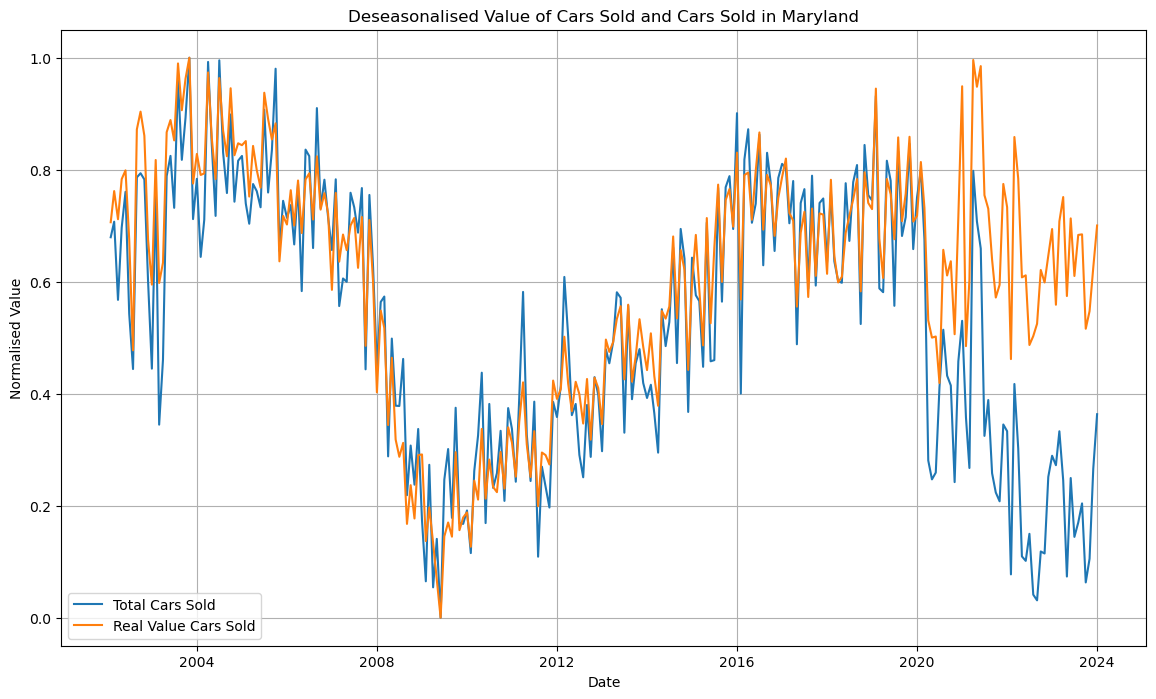

In [7]:
# plot multiple series
plot_multiple_series_one_xvalues(cyclical_data.index,[normalise_cyclical_data['total_cars_sold'],normalise_cyclical_data['real_value_cars_sold']],
                                 ['Total Cars Sold','Real Value Cars Sold'],'Deseasonalised Value of Cars Sold and Cars Sold in Maryland','Date','Normalised Value')

##### Observations
The movement of total cars sold and real value of cars sold follows the same pattern until 2020 when there is a large disruption to global supply chains and the average price of car paid has increased. Potential reasons for an increase in the amount paid for a car. The first part of this chapter is going to be looking at the cars sold from 2002-2020-03-01.

In [35]:
# load in economic data
economic_data = pd.read_csv('/Users/ben_nicholson/Visual_Code_Projects/Personal_Projects/Maryland Automotive Industry/preprocessed_datasets/combined_data/economic_data.csv',index_col='date')
before_covid_economic_data = economic_data[economic_data.index<='2020-03-01']
before_covid_economic_data.index = pd.to_datetime(before_covid_economic_data.index)
before_covid_economic_data

,yoy_inflation,interest_rate,fuel_price,consumer_confidence,unemployment_rate,gdp_growth
date,,,,,,
2002-01-01,NaN,1.73,0.634,NaN,5.0,NaN
2002-02-01,NaN,1.74,0.631,NaN,5.0,0.376418
2002-03-01,NaN,1.73,0.764,NaN,5.0,0.375007
2002-04-01,NaN,1.75,0.941,NaN,4.9,0.373606
2002-05-01,NaN,1.75,0.945,NaN,4.9,0.372215
...,...,...,...,...,...,...
2019-11-01,2.092290,1.55,1.710,101.3775,3.2,-0.121104
2019-12-01,2.319527,1.55,1.704,101.6001,3.3,-0.121251
2020-01-01,2.512264,1.55,1.667,101.5985,3.4,-0.121398


In [43]:
# normalise economic data
normalise_before_covid_economic_data = normalize_data(before_covid_economic_data)
normalise_before_covid_economic_data

,yoy_inflation,interest_rate,fuel_price,consumer_confidence,unemployment_rate,gdp_growth
date,,,,,,
2002-01-01,NaN,0.319846,0.001057,NaN,0.367347,NaN
2002-02-01,NaN,0.321773,0.000000,NaN,0.367347,0.624509
2002-03-01,NaN,0.319846,0.046847,NaN,0.367347,0.622738
2002-04-01,NaN,0.323699,0.109193,NaN,0.346939,0.620980
2002-05-01,NaN,0.323699,0.110602,NaN,0.346939,0.619236
...,...,...,...,...,...,...
2019-11-01,0.543308,0.285164,0.380063,0.946865,0.000000,0.000369
2019-12-01,0.573784,0.285164,0.377950,0.992638,0.020408,0.000185
2020-01-01,0.599633,0.285164,0.364917,0.992309,0.040816,0.000000


In [42]:
# create a separation of the data from 2016 to 2020
normalise_before_covid_sales_data = normalise_cyclical_data[normalise_cyclical_data.index <= '2020-03-01']
normalise_before_covid_sales_data.index= normalise_before_covid_sales_data.index - pd.offsets.MonthEnd(1) + pd.DateOffset(days=1)
normalise_before_covid_sales_data

,total_cars_sold,new_cars_sold,used_cars_sold,real_value_cars_sold,real_new_value_cars_sold,real_used_value_cars_sold
date,,,,,,
2002-01-01,0.679412,0.675302,0.596979,0.706221,0.668294,0.485656
2002-02-01,0.707199,0.732773,0.584653,0.761846,0.749001,0.471274
2002-03-01,0.567586,0.726070,0.364469,0.711591,0.740201,0.350029
2002-04-01,0.696533,0.790101,0.512485,0.783250,0.794141,0.457606
2002-05-01,0.760564,0.801298,0.602178,0.798899,0.795049,0.492883
...,...,...,...,...,...,...
2019-10-01,0.846062,0.551758,0.984868,0.858832,0.624898,0.975639
2019-11-01,0.658242,0.466677,0.787979,0.707406,0.516099,0.794440
2019-12-01,0.750995,0.469435,0.897881,0.717647,0.505622,0.835876


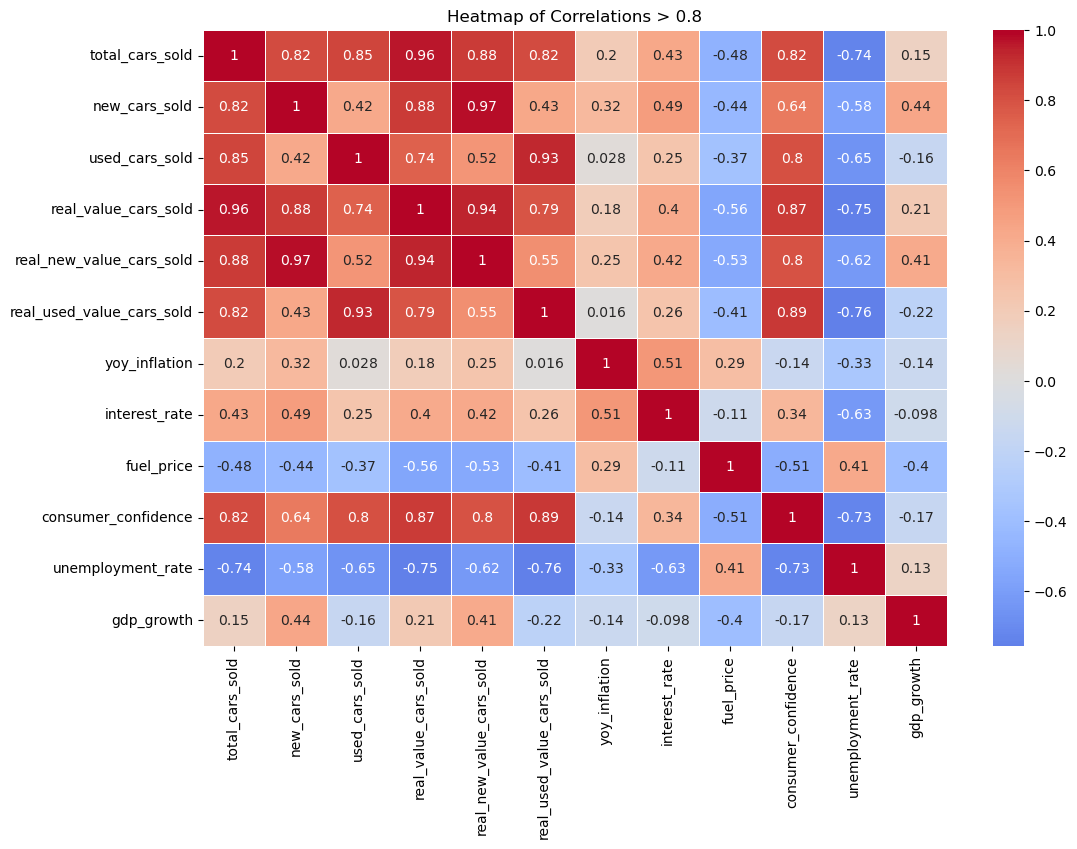

In [52]:
normalise_before_covid_combined_data = normalise_before_covid_sales_data.join(normalise_before_covid_economic_data)

import seaborn as sns
# Calculate the correlation matrix
corr_matrix = normalise_before_covid_combined_data.corr()

# Plot the heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, linewidths=0.5, linecolor='white')
plt.title('Heatmap of Correlations > 0.8')
plt.show()

In [45]:
# compare the correlation between total cars sold and real value of cars sold
normalise_before_covid_sales_data[['total_cars_sold','real_value_cars_sold']].corr()

,total_cars_sold,real_value_cars_sold
total_cars_sold,1.000000,0.960182
real_value_cars_sold,0.960182,1.000000


The correlation between total cars and real value of cars sold prior to 2020 was 96% meaning that the real average price of cars sold remained relatively stationary from 2002-2016.

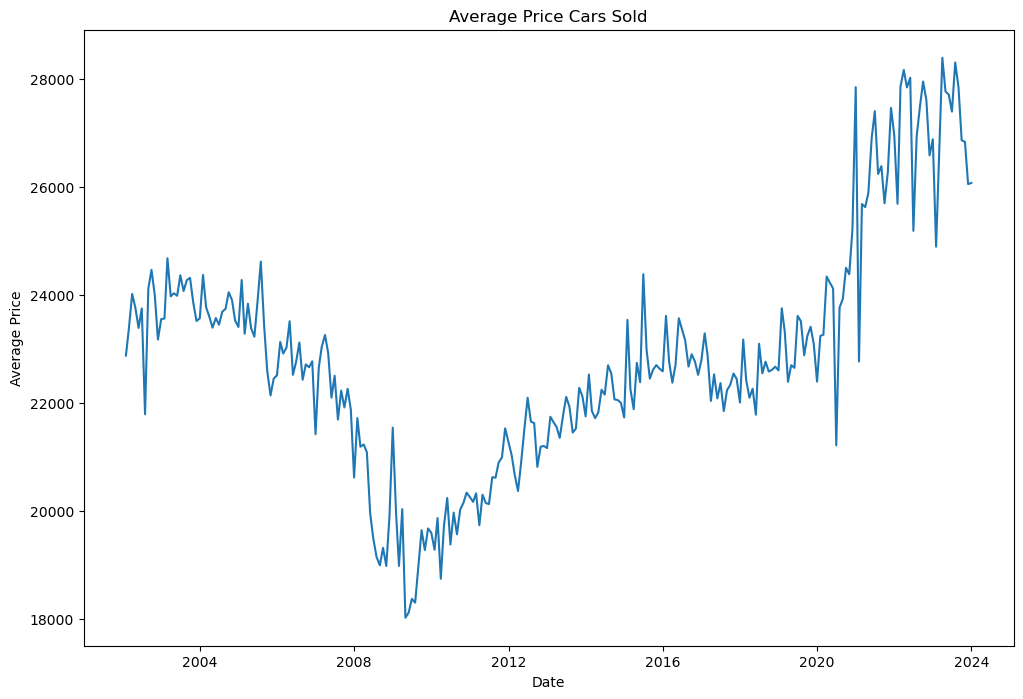

In [10]:
# average price of cars sold
cyclical_data['average_price'] = cyclical_data['real_value_cars_sold'] / cyclical_data['total_cars_sold']

line_series(cyclical_data.index,cyclical_data['average_price'],'Average Price Cars Sold','Date','Average Price')

In [11]:
# create average price
cyclical_data['average_price'] = cyclical_data['real_value_cars_sold'] / cyclical_data['total_cars_sold']
cyclical_data['new_average_price'] = cyclical_data['real_new_value_cars_sold'] / cyclical_data['new_cars_sold']
cyclical_data['used_average_price'] = cyclical_data['real_used_value_cars_sold'] / cyclical_data['used_cars_sold']

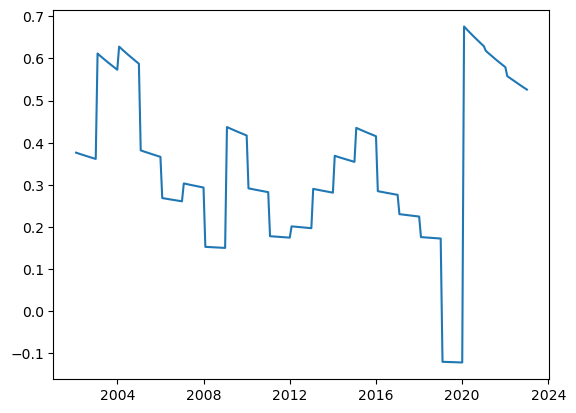

In [55]:
economic_data.index = pd.to_datetime(economic_data.index)
plt.plot(economic_data.index, economic_data['gdp_growth'])